# 01 – Análisis del mapa logístico

El mapa logístico es un sistema dinámico unidimensional clásico definido por

$$
x_{n+1} = r\,x_n(1 - x_n), \qquad 0 < r \le 4,\; 0 < x_n < 1.
$$

donde $r$ es un parámetro real. Para ciertos valores de $r$ el sistema presenta órbitas fijas o ciclos de periodo finito, mientras que para otros (por ejemplo $r \approx 3.99$) aparece un comportamiento fuertemente caótico.

En este notebook se estudiarán:

1. La evolución temporal de $x_n$ y el retrato de fase.
2. El atractor numérico del mapa logístico para parámetros clásicos.
3. Un diagrama tipo “bifurcación” al variar el parámetro $r$.
4. El exponente de Lyapunov máximo $\lambda(r)$.
5. El efecto del número de iteraciones transitorias al aproximar el atractor.
6. La justificación empírica del umbral de binarización en el generador de bits.
7. Las limitaciones numéricas debidas a la aritmética en coma flotante y sus implicaciones sobre el tamaño efectivo del espacio de claves.
8. Una breve conclusión con las ideas principales del análisis.

Además, en el apéndice se analiza:

- **Apéndice A – Sensibilidad del mapa logístico frente a pequeñas variaciones del parámetro $r$**, comparando dos órbitas con la misma condición inicial y parámetros $r$ y $r + \Delta r$.


## 0. Preparación del entorno

En esta sección se configura el entorno de trabajo:

- Se añade al `sys.path` la carpeta raíz del proyecto para poder importar los módulos de `analysis` y `utils`.

- Se importan las funciones auxiliares definidas en `analysis.logistic_analysis`, análogas a las usadas en los mapas de Hénon y *tent*:

  - `plot_orbit_logistic(...)` – dibuja la serie temporal de $x_n$ para un valor dado de $r$ y una condición inicial $x_0$.
  - `plot_attractor_logistic(...)` – visualiza el atractor numérico del mapa logístico representando los valores de $x_n$ tras descartar el transitorio.
  - `plot_bifurcation_logistic(...)` – genera un diagrama tipo bifurcación al variar el parámetro $r$.
  - `plot_lyapunov_vs_r_logistic(...)` – calcula y representa el exponente de Lyapunov máximo $\lambda(r)$.
  - `explore_transient_effect_logistic(...)` – estudia el efecto del número de iteraciones transitorias en estadísticas simples de la órbita.
  - `threshold_effect_logistic(...)` – calcula, para distintos umbrales de binarización $\theta$, la proporción de unos $p(1)$ de la secuencia resultante.
  - `plot_threshold_effect_logistic(...)` – representa gráficamente $p(1)$ en función del umbral $\theta$.
  - `detect_cycle_logistic(...)` – busca de forma aproximada ciclos periódicos en una órbita larga del mapa logístico.
  - `divergence_two_orbits_logistic(...)` – calcula la divergencia de dos órbitas con condiciones iniciales muy próximas.
  - `plot_divergence_two_orbits_logistic(...)` – representa gráficamente esa divergencia, normalmente en escala semilogarítmica.

- **Función para el apéndice:**

  - `plot_divergence_two_params_logistic(...)` – analiza la sensibilidad del sistema frente a pequeñas variaciones del parámetro $r$ comparando dos órbitas con la misma condición inicial.

- Además, se importan utilidades numéricas genéricas desde `utils.numerics_utils`, independientes del mapa concreto:

  - `float_spacing_around_05(...)` – estima la separación entre números de doble precisión alrededor de $x = 0.5$.
  - `interval_capacity(...)` – calcula el número aproximado de valores `float64` distintos en un intervalo de longitud $L$.
  - `bits_from_interval(...)` – estima los bits de entropía aportados por una variable real restringida a un intervalo de longitud $L$.


In [1]:
import os
import sys

# Añadimos la carpeta raíz del proyecto (una arriba de notebooks)
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from analysis.logistic_analysis import (
    plot_orbit_logistic,
    plot_attractor_logistic,
    plot_bifurcation_logistic,
    plot_lyapunov_vs_r_logistic,
    explore_transient_effect_logistic,
    plot_threshold_effect_logistic,
    detect_cycle_logistic,       
    plot_divergence_two_orbits_logistic,  
    # Funciones añadidas para los apéndices
    plot_divergence_two_params_logistic,
)

from utils.numerics_utils import (
    float_spacing_around_05,
    interval_capacity,
    bits_from_interval,
)


## 1. Órbitas del mapa logístico para distintos valores de $r$

Recordamos la ecuación del mapa logístico:

$$
x_{n+1} = r\,x_n(1 - x_n).
$$

Para distintos valores del parámetro $r$ se observa un comportamiento muy distinto:

- Para valores relativamente pequeños, la órbita converge a un **punto fijo**.
- Al aumentar $r$, aparecen **ciclos periódicos** de periodo 2, 4, 8, etc.
- Para valores de $r$ suficientemente grandes, el sistema entra en una región
  de **comportamiento caótico**, donde las órbitas parecen (visualmente) aleatorias.

En las celdas siguientes se representan las órbitas para varios valores de $r$
tomando una condición inicial fija $x_0 = 0.2$. Esto permite comparar:

- $r = 2.8$: régimen estable (punto fijo).
- $r = 3.2$: ciclo de periodo pequeño.
- $r = 3.5$: ciclo de periodo 4.
- $r = 3.8$, $r = 3.99$: comportamiento caótico.


r = 2.8


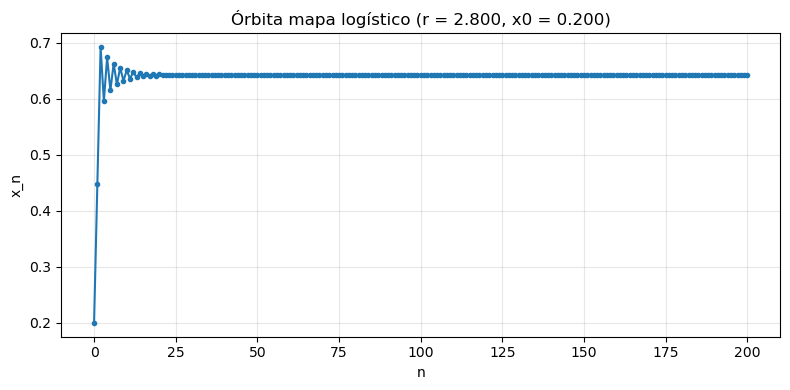

r = 3.2


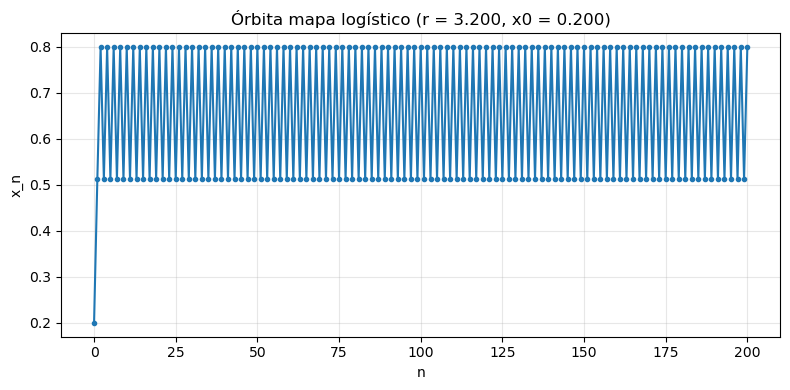

r = 3.5


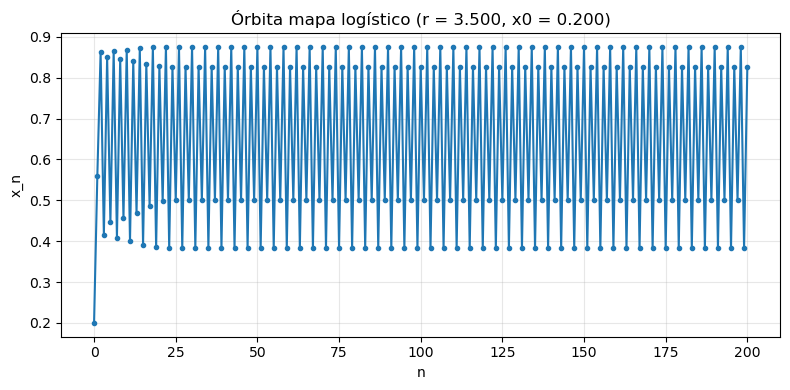

r = 3.8


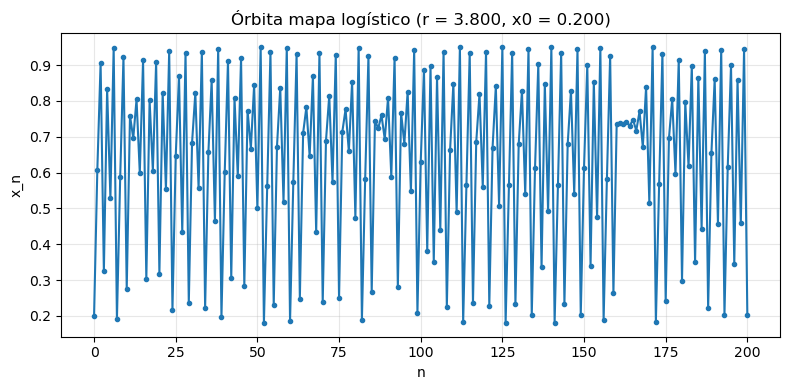

r = 3.99


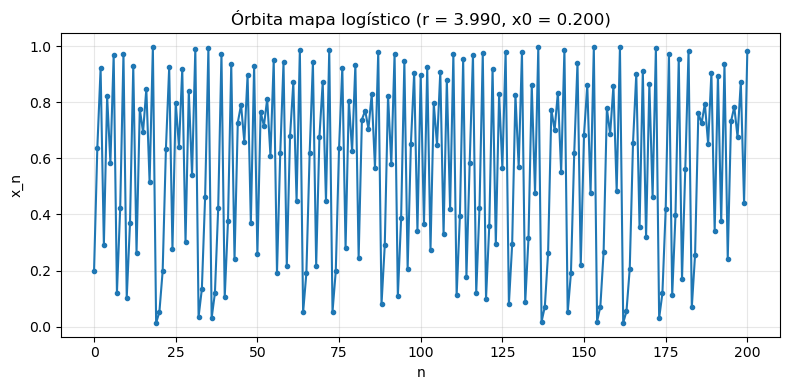

In [2]:
x0 = 0.2
rs = [2.8, 3.2, 3.5, 3.8, 3.99]

for r in rs:
    print(f"r = {r}")
    plot_orbit_logistic(x0=x0, r=r, n_iters=200)


#### Interpretación de las órbitas para distintos valores de $r$

Las cinco gráficas muestran la evolución temporal $x_n$ del mapa logístico
para un mismo valor inicial $x_0 = 0.2$ y distintos valores del parámetro $r$.
Se observa claramente la transición desde un comportamiento regular a uno
caótico:

- **$r = 2.8$**  
  La órbita converge rápidamente a un **punto fijo estable**. Tras un breve
  transitorio, todos los valores se agrupan en torno a un único valor de
  equilibrio.

- **$r = 3.2$**  
  El punto fijo se vuelve inestable y aparece un **ciclo de periodo 2**: la
  órbita alterna entre dos valores distintos de forma periódica.

- **$r = 3.5$**  
  La dinámica pasa a un **ciclo de mayor periodo** (periodos $4, 8, \dots$),
  visible como una órbita que salta entre varios niveles, pero todavía con una
  estructura claramente repetitiva.

- **$r = 3.8$**  
  La órbita muestra ya un comportamiento **aparentemente irregular**, aunque
  aún pueden apreciarse ciertas bandas o patrones. El sistema se encuentra en
  una región intermedia, con coexistencia de estructuras periódicas y caóticas.

- **$r = 3.99$**  
  La órbita es fuertemente **caótica**: los valores de $x_n$ exploran gran
  parte del intervalo $(0,1)$ de forma muy irregular, sin repetición visible en
  la escala temporal representada. Esta es la región de interés para el
  generador de bits, ya que proporciona una dinámica muy sensible a las
  condiciones iniciales.


## 2. Atractor numérico para un valor caótico de $r$

En la zona caótica, la órbita del sistema no converge a un punto fijo ni a un 
ciclo de periodo finito, sino que "vive" sobre un **atractor extraño** dentro
del intervalo $[0,1]$.

Para aproximar este atractor de forma numérica:

1. Se fija un valor de $r$ en la región caótica (por ejemplo, $r = 3.99$).
2. Se descartan varias iteraciones **transitorias** (por ejemplo, 1000 pasos),
   de forma que la órbita se acerque al atractor.
3. A continuación se representan únicamente los últimos $n$ valores de la órbita.

La figura siguiente muestra los puntos $x_n$ (en el eje vertical) en función
del índice $n$ (en el eje horizontal) tras descartar el transitorio.
Esto da una idea de la distribución de valores que ocupa la órbita en régimen 
"estacionario".


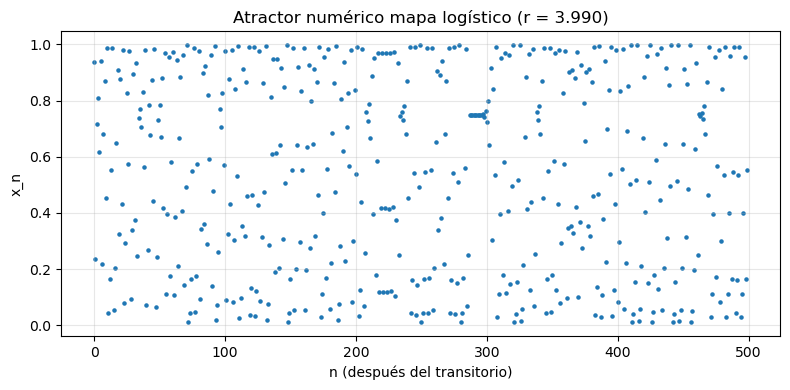

In [3]:
r_caotico = 3.99
plot_attractor_logistic(r=r_caotico, x0=0.2, n_transient=1000, n_points=500)


#### Interpretación del atractor numérico para $r = 3.99$

La figura muestra el atractor numérico del mapa logístico para un valor
caótico del parámetro, concretamente $r = 3.99$. Tras descartar las
iteraciones transitorias, se representan únicamente los últimos puntos de la
órbita $x_n$.

Se observa que:

- Los valores de $x_n$ se dispersan por gran parte del intervalo $(0,1)$,
  sin concentrarse en un número finito de niveles, lo que indica la ausencia de
  puntos fijos o ciclos de pequeño periodo.
- Aun así, la distribución no es completamente uniforme: ciertas franjas del
  intervalo se visitan con mayor frecuencia que otras, reflejando la estructura
  del atractor caótico.

Este tipo de atractor es el que se utilizará como base para el generador de
bits, ya que proporciona una órbita rica y muy sensible a la condición inicial.


## 3. Diagrama de bifurcación

El **diagrama de bifurcación** del mapa logístico representa, para cada valor del
parámetro $r$, los valores posibles de $x_n$ en régimen estacionario 
(es decir, después de descartar el transitorio).

Procedimiento numérico:

1. Se recorre un intervalo de valores de $r$ (por ejemplo, de 2.5 a 4.0).
2. Para cada $r$:
   - se simula la órbita desde una condición inicial $x_0$,
   - se descartan $n_\text{transient}$ iteraciones,
   - se representan los siguientes $n_\text{plot}$ valores de $x_n$.

En el diagrama resultante se observa claramente:

- la aparición de **bifurcaciones de periodo** (1 → 2 → 4 → 8 → …),
- la transición a la región **caótica**,
- la presencia de **ventanas periódicas** dentro del caos.

Este diagrama es una de las representaciones clásicas del comportamiento 
no lineal y caótico del mapa logístico.


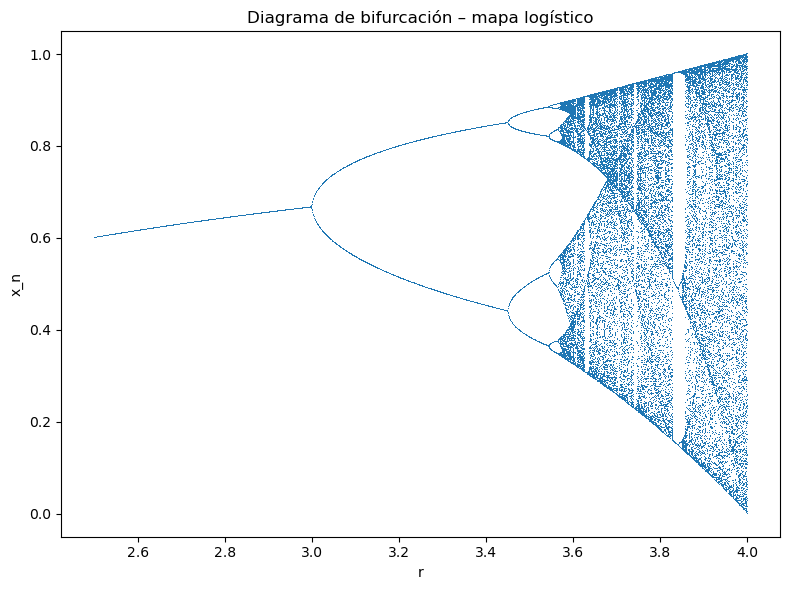

In [4]:
plot_bifurcation_logistic(
    r_min=2.5,
    r_max=4.0,
    r_points=1500,   # puedes subir a 2000 si va fluido
    x0=0.5,
    n_transient=1000,
    n_plot=80,
)


#### Interpretación del diagrama de bifurcación

El diagrama de bifurcación representa, para cada valor de $r$ en el intervalo
considerado, los valores posibles de $x_n$ en régimen estacionario.

En él se aprecia claramente:

- Una zona inicial donde aparece un **punto fijo estable** (una única rama).
- Una sucesión de **bifurcaciones de periodo** que da lugar a ciclos de periodo
  $2, 4, 8, \dots$.
- A partir de ciertos valores de $r$, la transición a una región
  claramente **caótica**, donde las ramas se ensanchan y forman bandas
  continuas de puntos.
- La presencia de **ventanas periódicas** dentro del caos, donde reaparecen
  ciclos de periodo finito.

Si nos fijamos en valores de $r$ próximos a $3.99$, observamos un conjunto
denso de puntos, indicativo de un régimen caótico fuerte. Esta es la zona en la
que se sitúan los parámetros utilizados posteriormente para generar bitstreams
pseudoaleatorios.


## 4. Exponente de Lyapunov en función de $r$

El **exponente de Lyapunov** $\lambda$ mide la sensibilidad a las condiciones 
iniciales. En el caso unidimensional del mapa logístico, se puede aproximar mediante:

$$
\lambda(r) \approx \frac{1}{N} \sum_{n=0}^{N-1} 
\log \left| f'(x_n) \right|,
\quad \text{con } f'(x) = r(1 - 2x).
$$

Interpretación:

- Si $\lambda(r) < 0$, las órbitas cercanas tienden a acercarse → comportamiento estable.
- Si $\lambda(r) > 0$, las órbitas cercanas divergen de forma exponencial → **caos**.

En la figura siguiente se representa $\lambda(r)$ para el mismo rango de valores 
de $r$ utilizado en el diagrama de bifurcación. Se observa que:

- En las zonas donde el diagrama muestra un punto fijo o ciclos periódicos,
  $\lambda(r)$ es negativo.
- En las regiones caóticas, $\lambda(r)$ toma valores positivos.


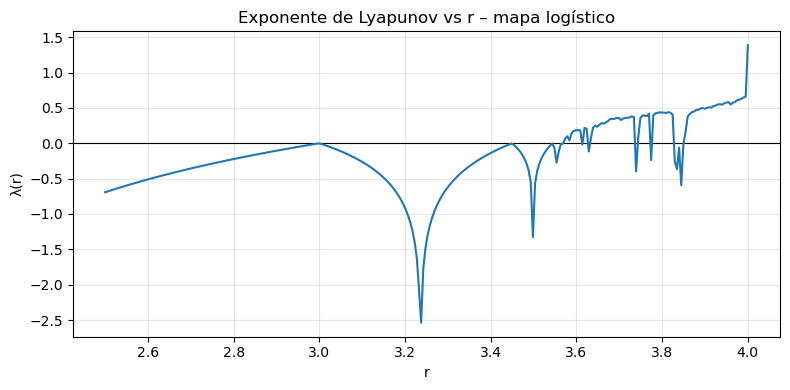

In [5]:
plot_lyapunov_vs_r_logistic(
    r_min=2.5,
    r_max=4.0,
    r_points=300,
    x0=0.5,
    n_transient=1000,
    n_iters=3000,
)


#### Interpretación del exponente de Lyapunov $\lambda(r)$

La gráfica del exponente de Lyapunov $\lambda(r)$ proporciona una medida
cuantitativa de la sensibilidad a las condiciones iniciales para cada valor de
$r$.

- En las regiones donde $\lambda(r) < 0$, las órbitas cercanas tienden a
  converger: el sistema evoluciona hacia puntos fijos o ciclos estables.
- En las regiones donde $\lambda(r) > 0$, el sistema presenta
  **sensibilidad exponencial a las condiciones iniciales**: pequeñas diferencias
  en $x_0$ crecen de forma rápida, lo que es característico de la dinámica
  caótica.

Para valores de $r$ próximos a $3.99$, el exponente de Lyapunov es claramente
positivo. Esto confirma que el mapa logístico opera en un régimen caótico
fuerte precisamente en el rango de parámetros que se selecciona para el
generador de bits.


## 5. Justificación empírica del número de iteraciones transitorias

En el resto del trabajo (por ejemplo, al generar bitstreams caóticos) se descartan 
varias miles de iteraciones transitorias antes de utilizar los valores del sistema.
La intuición es que, tras un cierto tiempo, la órbita "olvida" la condición inicial 
y se aproxima al atractor.

Para justificar de forma empírica el orden de magnitud del transitorio, en esta 
sección se estudia cómo varía una estadística sencilla (la **media** de $x_n$) 
cuando se descartan distintos números de iteraciones $T$:

1. Se genera una órbita larga ($n_\text{total}$ iteraciones) para un valor 
   caótico de $r$.
2. Para distintos valores de $T$ (0, 500, 1000, …), se calcula la media de 
   $x_n$ desde $n = T$ hasta el final.
3. Se representa la media en función de $T$.

Si la curva se estabiliza a partir de un cierto valor de $T$, esto sugiere que 
descartar un transitorio de ese orden de magnitud es suficiente para que las 
estadísticas básicas de la órbita ya no dependan de la condición inicial.

Esta observación respalda la elección de valores como 
$n_\text{transient} \approx 2000{-}5000$ utilizada en el resto del proyecto.


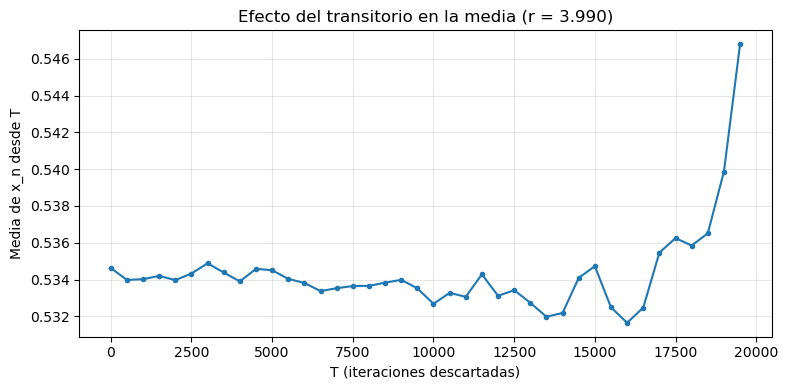

In [6]:
explore_transient_effect_logistic(
    r=3.99,
    x0=0.2,
    n_total=20_000,
    step=500,
)


#### Interpretación del efecto del número de iteraciones transitorias

La figura muestra la media de $x_n$ calculada desde $n = T$ hasta el final de
la órbita, en función del número de iteraciones transitorias $T$ que se
descartan, para $r = 3.99$.

Se observa que:

- Para valores pequeños de $T$, la media todavía puede verse afectada por la
  condición inicial y presenta ligeras variaciones.
- A partir de unos pocos miles de iteraciones descartadas (del orden de
  $T \approx 2000$–$5000$), la media se estabiliza alrededor de un valor
  casi constante, lo que indica que la influencia del estado inicial es ya muy
  reducida.
- El aumento brusco que aparece cuando $T$ se acerca demasiado al número total
  de iteraciones está relacionado con el hecho de que se promedia sobre muy
  pocos puntos y no es relevante para la elección del transitorio.

Esta observación respalda la elección de $n_{\text{transient}} = 5000$ como
valor de referencia en el resto del trabajo: es un compromiso razonable entre
eliminar el transitorio y no desperdiciar demasiadas iteraciones útiles.


## 6. Justificación empírica del umbral de binarización

En el generador de bits basado en el mapa logístico, cada valor de la órbita se
transforma en un bit mediante la regla

$$
\text{bit}_n =
\begin{cases}
1 & \text{si } x_n > \theta,\\
0 & \text{en otro caso}.
\end{cases}
$$

donde $\theta \in (0,1)$ es el **umbral de binarización**.  
Intuitivamente, si la órbita visita de forma “equilibrada” las regiones por encima
y por debajo de $\theta$, la secuencia resultante tendrá una proporción de ceros
y unos aproximadamente igual.

Desde el punto de vista teórico, el valor $\theta = 0{.}5$ es un candidato natural:

- En el mapa logístico $f(x) = r x (1-x)$, el punto $x = 0{.}5$ es el **máximo**
  de la parábola y actúa como **punto crítico** que divide el intervalo $[0,1]$
  en dos ramas.
- En la región caótica (valores de $r$ próximos a 4), la órbita explora el intervalo
  de forma compleja y visitar las dos regiones $[0,0.5]$ y $(0.5,1]$ con
  probabilidades similares es razonable.

Para complementar esta intuición, se realiza un estudio empírico del efecto del
umbral en el balance de ceros y unos:

1. Se genera una órbita larga del mapa logístico en la región caótica (para un
   valor de $r$ próximo a 4), descartando un transitorio fijo como el utilizado en la
   sección anterior.
2. A partir de los puntos del atractor, para distintos valores de $\theta$
   (por ejemplo, 0.1, 0.3, 0.5, 0.7 y 0.9) se calcula la secuencia de bits
   $b_n = \mathbb{1}_{\{x_n > \theta\}}$.
3. Para cada valor de $\theta$ se estima la proporción de unos $\hat p(1)$ como la
   fracción de valores $b_n$ iguales a 1.
4. Se representa gráficamente $\hat p(1)$ en función de $\theta$ y se compara con
   el valor ideal $\hat p(1) = 0.5$.

En código, utilizando las funciones auxiliares definidas en `logistic_analysis.py`:

```python
plot_threshold_effect_logistic(
    r=3.99,
    x0=0.2,
    n_transient=5000,
    n_points=1_000_000,
)


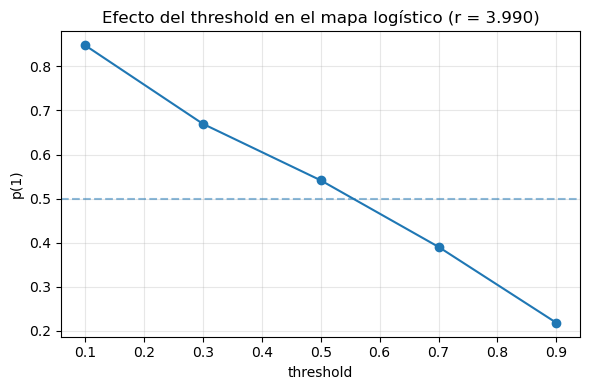

In [7]:
plot_threshold_effect_logistic(
    r=3.99,
    x0=0.2,
    n_transient=5000,
    n_points=1_000_000,
)


#### Interpretación del efecto del umbral de binarización

La gráfica representa la proporción de unos $p(1)$ en la secuencia binaria
obtenida a partir de la órbita del mapa logístico con $r = 3.99$, en función
del umbral de binarización $\theta$.

Las principales conclusiones son:

- Para umbrales bajos (por ejemplo, $\theta = 0.1$), la mayor parte de los
  valores $x_n$ superan el umbral, por lo que $p(1)$ es muy elevado y la
  secuencia está fuertemente sesgada hacia el bit $1$.
- Para umbrales altos (por ejemplo, $\theta = 0.9$), ocurre lo contrario:
  $p(1)$ es muy pequeño y la secuencia se sesga hacia el bit $0$.
- Para valores intermedios, y en particular para $\theta = 0.5$, la
  proporción de unos $p(1)$ se sitúa más cerca del valor ideal $0.5$,
  proporcionando una secuencia binaria más equilibrada.

Por este motivo, en el generador de bits basado en el mapa logístico se adopta
$\theta = 0.5$ como umbral de binarización por defecto.


## 7. Limitaciones numéricas y precisión en coma flotante (mapa logístico)

En este apartado se estudian algunos aspectos numéricos relacionados con la implementación del mapa logístico en coma flotante de doble precisión:

1. La resolución del formato `float64` y el número máximo de valores distintos que caben en un intervalo $(0,1)$.
2. Una estimación del tamaño del espacio de claves cuando se utilizan como parte de la clave el parámetro real $r$ y la condición inicial $x_0$.
3. La aparición (inevitable) de ciclos periódicos debidos al espacio de estados finito.
4. La divergencia de órbitas con condiciones iniciales muy próximas y su relación con el exponente de Lyapunov.

El objetivo es conectar la teoría caótica del mapa logístico con las limitaciones prácticas de la aritmética de coma flotante y del tamaño efectivo del *keyspace* en aplicaciones criptográficas basadas en este mapa.


### 7.1 Resolución numérica y valores distintos en $(0,1)$

Al igual que en el caso del mapa de Hénon, el mapa logístico se implementa con números en formato de doble precisión (`float64`). Esto implica que el intervalo $(0,1)$ no contiene un continuo de valores sino un conjunto discreto de puntos espaciados.

Para cuantificar esta resolución, se estudia la separación entre números de doble precisión alrededor de $x = 0.5$ mediante la función `float_spacing_around_05()`. A partir de esa separación $\varepsilon$ se puede estimar cuántos valores diferentes caben en el intervalo $(0,1)$ y cuántos bits de entropía binaria aportaría una variable real restringida a dicho intervalo.


In [8]:
# 7.1 Tamaño del keyspace asociado a variables reales en doble precisión (logístico)

eps_info = float_spacing_around_05()

print("Resolución numérica en doble precisión alrededor de x = 0.5")
print("-" * 70)
print(f"x       = {eps_info['x']}")
print(f"x_prev  = {eps_info['x_prev']}")
print(f"x_next  = {eps_info['x_next']}")
print()
print(f"eps_minus = x - x_prev   ≈ {eps_info['eps_minus']:.3e}")
print(f"eps_plus  = x_next - x   ≈ {eps_info['eps_plus']:.3e}")
print()
print(f"N_vals  ≈ {eps_info['n_vals_interval']:.3e} valores distintos en el intervalo (0,1)")
print(f"Bits    ≈ {eps_info['log2_n_vals_interval']:.2f} bits de entropía binaria")


Resolución numérica en doble precisión alrededor de x = 0.5
----------------------------------------------------------------------
x       = 0.5
x_prev  = 0.49999999999999994
x_next  = 0.5000000000000001

eps_minus = x - x_prev   ≈ 5.551e-17
eps_plus  = x_next - x   ≈ 1.110e-16

N_vals  ≈ 9.007e+15 valores distintos en el intervalo (0,1)
Bits    ≈ 53.00 bits de entropía binaria


La salida numérica muestra que:

- La separación entre números de doble precisión alrededor de $x = 0.5$ es del orden de $2^{-52} \approx 2.2 \cdot 10^{-16}$.
- En consecuencia, el intervalo $(0,1)$ contiene como máximo del orden de $N \approx 2^{52} \approx 4.5 \cdot 10^{15}$ valores distintos representables.
- Esto equivale a unos $52$ bits de entropía binaria para una variable real acotada en $(0,1)$ cuando se representa en `float64`.

Este orden de magnitud será la base para estimar el tamaño del espacio de claves asociado al parámetro $r$ y a la condición inicial $x_0$ del mapa logístico.


### 7.2 Estimación del espacio de claves basado en $(r, x_0)$

Supongamos que en un esquema criptográfico se utilizan como parte de la clave:

- el parámetro $r$ restringido a una región caótica, por ejemplo $r \in [3.9, 4.0]$,
- la condición inicial $x_0$ restringida al intervalo $(0,1)$.

Si ambas variables se representan en doble precisión, el número aproximado de valores distintos que puede tomar cada una viene dado por la capacidad del intervalo correspondiente. Usando `interval_capacity(L)` y `bits_from_interval(L)` podemos estimar tanto el número de valores posibles como los bits de entropía aportados por cada componente de la clave.


In [9]:
# 7.2 Estimación del espacio de claves basado en (r, x0) – mapa logístico

# Intervalos en la región caótica
r_min, r_max = 3.9, 4.0   # por ejemplo, parte superior del diagrama de bifurcación
L_r = r_max - r_min

L_x0 = 1.0                # x0 en (0,1)

info_r  = interval_capacity(L_r)
info_x0 = interval_capacity(L_x0)

N_r  = info_r["N_vals"]
N_x0 = info_x0["N_vals"]

bits_r  = info_r["log2_N_vals"]
bits_x0 = info_x0["log2_N_vals"]

total_bits = bits_r + bits_x0

print("Mapa logístico – estimación del espacio de claves basado en (r, x0)")
print("-" * 72)
print()
print(f"Intervalo para r  : [{r_min}, {r_max}]")
print(f"  L_r = {L_r}")
print(f"  Valores distintos aproximados de r   ~ {N_r:.3e}")
print(f"  Bits de entropía aportados por r     ~ {bits_r:.2f} bits")
print()
print("Intervalo para x0 : (0, 1)")
print(f"  L_x0 = {L_x0}")
print(f"  Valores distintos aproximados de x0  ~ {N_x0:.3e}")
print(f"  Bits de entropía aportados por x0    ~ {bits_x0:.2f} bits")
print()
print(f"Bits de entropía combinados (r, x0)    ~ {total_bits:.2f} bits")
print(f"Equivalente a un espacio de claves del orden de 2^{total_bits:.1f}")


Mapa logístico – estimación del espacio de claves basado en (r, x0)
------------------------------------------------------------------------

Intervalo para r  : [3.9, 4.0]
  L_r = 0.10000000000000009
  Valores distintos aproximados de r   ~ 9.007e+14
  Bits de entropía aportados por r     ~ 49.68 bits

Intervalo para x0 : (0, 1)
  L_x0 = 1.0
  Valores distintos aproximados de x0  ~ 9.007e+15
  Bits de entropía aportados por x0    ~ 53.00 bits

Bits de entropía combinados (r, x0)    ~ 102.68 bits
Equivalente a un espacio de claves del orden de 2^102.7


En la salida se observa que, aproximadamente:

- El parámetro $r$ en $[3.9, 4.0]$ aporta del orden de $N_r$ valores distintos y unos $b_r \approx 50$ bits de entropía.
- La condición inicial $x_0$ en $(0,1)$ aporta del orden de $N_{x_0}$ valores distintos y unos $b_{x_0} \approx 53$ bits de entropía.

En conjunto, el par $(r, x_0)$ ofrece un espacio de claves efectivo del orden de $2^{B}$ estados posibles, donde $B$ es la suma de los bits aportados por cada variable (en este ejemplo, del orden de unos $100$ bits de entropía).

Al igual que en el caso del mapa de Hénon, esta estimación es una **cota superior teórica** basada únicamente en la resolución de `float64` y en la longitud de los intervalos considerados. El espacio de claves efectivo puede ser menor si:

- se restringe aún más la región de $r$ para garantizar buen comportamiento caótico,
- ciertas combinaciones de $(r, x_0)$ producen órbitas no deseadas (por ejemplo, ciclos de periodo pequeño),
- o el diseño del esquema criptográfico impone restricciones adicionales sobre los parámetros.

No obstante, la estimación indica que el mapa logístico, incluso en esta versión sencilla, dispone de un espacio de claves razonablemente amplio cuando se usan $r$ y $x_0$ en doble precisión.


### 7.3 Búsqueda de ciclos en una órbita larga

Debido a que la aritmética de doble precisión sólo permite un número finito de estados, toda órbita del mapa logístico acaba siendo periódica: en algún momento se repite el valor de $x_n$ y, a partir de ahí, la dinámica entra en un ciclo.

Para ilustrar este fenómeno, se genera una órbita larga y se utiliza la función `detect_cycle_logistic(...)` para ver si aparece un ciclo dentro de las primeras iteraciones, usando igualdad exacta de coma flotante.


In [10]:
# 7.3 Búsqueda aproximada de ciclos en una órbita del mapa logístico

r_c = 3.99
x0_c = 0.2

n0, n1 = detect_cycle_logistic(
    r=r_c,
    x0=x0_c,
    n_iters_max=1_000_000,
)

print(f"Parámetros: r = {r_c}, x0 = {x0_c}")
if n0 is None:
    print("No se ha detectado ningún ciclo dentro de las primeras 1e6 iteraciones (igualdad exacta).")
else:
    period = n1 - n0
    print(f"Se ha detectado repetición exacta: x_{n0} = x_{n1}")
    print(f"Periodo aproximado del ciclo: k ≈ {period}")


Parámetros: r = 3.99, x0 = 0.2
No se ha detectado ningún ciclo dentro de las primeras 1e6 iteraciones (igualdad exacta).


En los valores caóticos $r \approx 3.99$ ocurre que:

- No se detectan ciclos de periodo pequeño dentro del límite de iteraciones buscado (por ejemplo $10^6$), lo que es consistente con una dinámica compleja.
- Sin embargo, desde el punto de vista teórico y numérico sabemos que, al trabajar en un espacio de estados finito, la órbita debe acabar entrando en algún ciclo de periodo finito, posiblemente muy largo.

Este experimento ilustra que la finitud de la representación numérica introduce, de forma inevitable, periodicidad en un sistema que, en el modelo matemático ideal, puede presentar órbitas no periódicas.


### 7.4 Divergencia de órbitas con condiciones iniciales próximas

Una característica clave del comportamiento caótico en el mapa logístico es la sensibilidad extrema a las condiciones iniciales: dos órbitas que parten de puntos muy cercanos se separan rápidamente con el tiempo.

La función `plot_divergence_two_orbits_logistic(...)` representa la distancia
$|x_n^{(1)} - x_n^{(2)}|$ entre dos órbitas que difieren inicialmente en una cantidad muy pequeña $\delta_0$ en la condición inicial $x_0$, usando escala semilogarítmica para resaltar la fase de crecimiento casi exponencial.


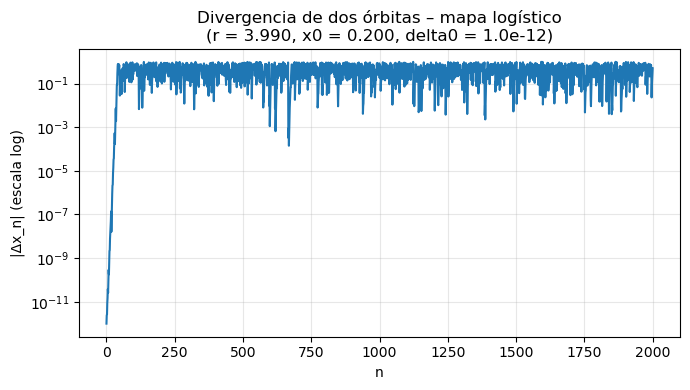

In [11]:
# 7.4 Divergencia de dos órbitas con condiciones iniciales próximas – mapa logístico

plot_divergence_two_orbits_logistic(
    r=3.99,
    x0=0.2,
    delta0=1e-12,
    n_iters=2_000,
    log_scale=True,
)


En la gráfica se observa que:

- Al principio la distancia entre órbitas crece de forma aproximadamente exponencial, lo que se manifiesta como un tramo casi lineal al representar $\log |x_n^{(1)} - x_n^{(2)}|$ frente a $n$.
- Después de cierto tiempo, la distancia se satura porque ambas órbitas están confinadas en el intervalo $(0,1)$ y porque la precisión finita de `float64` impide diferencias arbitrariamente pequeñas.

Esta divergencia rápida de órbitas cercanas es la manifestación numérica de la sensibilidad a las condiciones iniciales en el mapa logístico y está en consonancia con la presencia de un exponente de Lyapunov positivo $\lambda(r) > 0$ en la región caótica.


## 8. Conclusiones del análisis del mapa logístico

A partir de los resultados obtenidos en este notebook se pueden extraer varias conclusiones:

- El mapa logístico presenta una rica variedad de comportamientos al variar el parámetro $r$: desde puntos fijos estables hasta dinámicas claramente caóticas. Las órbitas y el retrato temporal permiten visualizar de forma intuitiva esta transición.

- El diagrama de bifurcación muestra la cascada de duplicación de periodo y la aparición de ventanas periódicas dentro de la región caótica. Este diagrama es una de las representaciones clásicas del paso del orden al caos en sistemas unidimensionales.

- El exponente de Lyapunov $\lambda(r)$ proporciona una medida cuantitativa de la sensibilidad a las condiciones iniciales. En la región donde $\lambda(r) > 0$ el sistema es caótico y pequeñas diferencias en $x_0$ crecen de forma aproximadamente exponencial.

- El estudio del transitorio indica que descartar algunas miles de iteraciones antes de utilizar la órbita es una práctica razonable para reducir la influencia de la condición inicial en las estadísticas del sistema.

- La justificación del umbral de binarización muestra que elegir $\theta = 0.5$ (punto crítico de la parábola) es natural para obtener un balance razonablemente equilibrado entre ceros y unos en las secuencias de bits.

- El análisis numérico en doble precisión `float64` revela que:
  - el intervalo $(0,1)$ contiene del orden de $2^{52}$ valores distintos representables,
  - los parámetros reales $(r, x_0)$ pueden aportar del orden de cien bits de entropía binaria,
  - pero el espacio de estados es finito, de modo que toda órbita acaba entrando en un ciclo, y la dinámica efectiva depende de la resolución de la aritmética de coma flotante.

En conjunto, el mapa logístico ofrece un ejemplo sencillo pero muy rico de sistema caótico: es fácil de implementar, permite construir generadores de bits basados en su dinámica y, al mismo tiempo, ilustra las limitaciones prácticas que impone la computación en precisión finita.


## Apéndice A – Sensibilidad del mapa logístico frente a pequeñas variaciones del parámetro $r$

En esta sección se estudia cómo afecta una pequeña variación del parámetro $r$ a la evolución del mapa logístico cuando se mantiene fija la condición inicial.

Consideramos dos órbitas:

- Órbita 1: parámetro $r$ y condición inicial $x_0$.
- Órbita 2: parámetro $r + \Delta r$ y la misma condición inicial $x_0$.

En cada iteración se mide la distancia

$$
d_n = \lvert x_n^{(r)} - x_n^{(r + \Delta r)} \rvert,
$$

y se representa $d_n$ en función de $n$, normalmente en escala semilogarítmica, para visualizar mejor una posible fase de crecimiento exponencial de la diferencia.


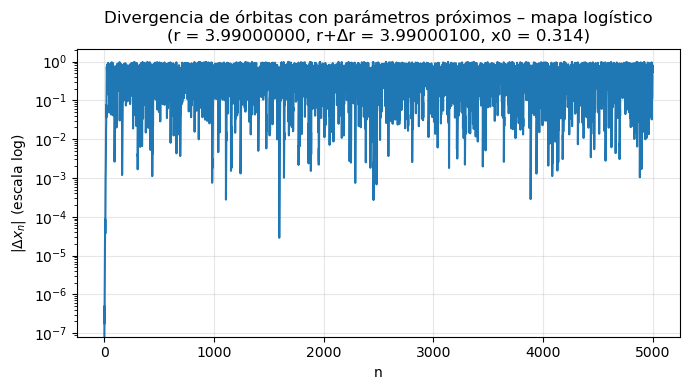

In [12]:
# Apéndice A – Sensibilidad al parámetro r en el mapa logístico

r_caotico = 3.99
x0 = 0.314159

plot_divergence_two_params_logistic(
    r=r_caotico,
    delta_r=1e-6,
    x0=x0,
    n_iters=5_000,
    log_scale=True,
)


### Interpretación del experimento de sensibilidad en $r$

La gráfica anterior muestra la evolución de la distancia $d_n = \lvert x_n^{(r)} - x_n^{(r + \Delta r)} \rvert$ entre dos órbitas del mapa logístico que comparten condición inicial pero difieren ligeramente en el parámetro $r$.

Se observa típicamente que:

- Existe una primera fase en la que $d_n$ crece de forma aproximadamente exponencial, lo que se refleja como un tramo casi lineal en la escala semilogarítmica.  
  Esto es coherente con la presencia de un exponente de Lyapunov positivo en la región caótica.

- Tras cierto número de iteraciones, la distancia deja de crecer y se satura alrededor de un valor máximo del orden de la amplitud del intervalo $(0,1)$.  
  Esta saturación se debe a que ambas órbitas permanecen acotadas y a que la aritmética en coma flotante sólo distingue un número finito de estados posibles.

Este experimento ilustra que, además de la sensibilidad a la condición inicial, el mapa logístico también es sensible a pequeñas variaciones del parámetro $r$: dos valores de $r$ que difieren sólo en $\Delta r \approx 10^{-6}$ pueden generar órbitas que, al cabo de cierto tiempo, son prácticamente independientes desde el punto de vista numérico.
